In [8]:
# imports and a consistent RNG
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
rng = np.random.default_rng(2025)

def moving_average(a, k=10):
    if k <= 1 or len(a) == 0:
        return a
    k = min(k, len(a))
    c = np.convolve(a, np.ones(k)/k, mode="valid")
    pad = np.full(k-1, c[0])
    return np.concatenate([pad, c])

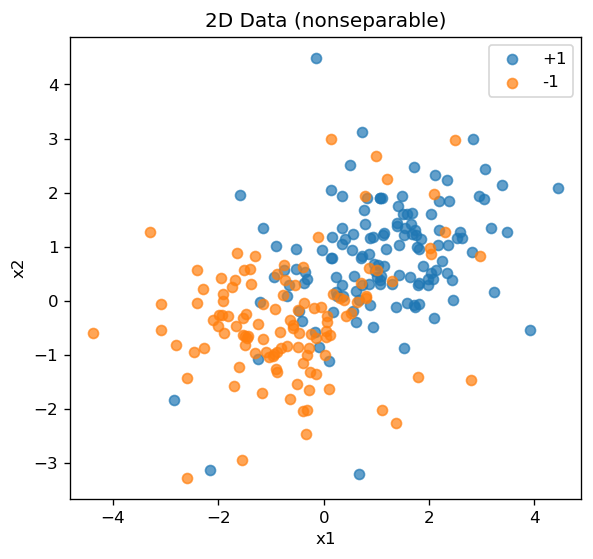

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def rot(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],[s, c]])

def make_separable(rng, n_total=240, pos_frac=0.55, margin=0.6, sep=2.8, max_tries=200000):
    """
    Guaranteed linearly separable in R^2 by enforcing y*(w^T x + b) >= margin.
    """
    n_pos = int(pos_frac * n_total)
    n_neg = n_total - n_pos

    # True separating hyperplane (unknown to the learner)
    w = np.array([1.0, 0.6], dtype=float)
    w = w / (np.linalg.norm(w) + 1e-12)
    b = 0.0

    # Elliptical covariances (tight enough to reduce rejections)
    S_pos = rot(np.deg2rad(25)) @ np.diag([0.6, 0.22]) @ rot(np.deg2rad(25)).T
    S_neg = rot(np.deg2rad(-15)) @ np.diag([0.6, 0.22]) @ rot(np.deg2rad(-15)).T

    # Means placed on opposite sides along w
    mu_pos =  sep * w + np.array([0.15, 0.00])
    mu_neg = -sep * w + np.array([-0.15, 0.00])

    X, y = [], []
    tries = 0

    while len(y) < n_total and tries < max_tries:
        tries += 1
        want_pos = (len(y) < n_pos)
        if want_pos:
            x = rng.multivariate_normal(mu_pos, S_pos)
            label = 1.0
        else:
            x = rng.multivariate_normal(mu_neg, S_neg)
            label = -1.0

        score = w @ x + b
        if label * score >= margin:
            X.append(x)
            y.append(label)

    if len(y) < n_total:
        raise RuntimeError("Could not generate enough separable points. Increase sep or lower margin/cov.")

    X = np.array(X)
    y = np.array(y)

    perm = rng.permutation(len(X))
    X, y = X[perm], y[perm]

    split = int(0.8 * len(X))
    return X, y, X[:split], y[:split], X[split:], y[split:]


def make_nonseparable(rng, n_total=240, pos_frac=0.55, flip_rate=0.08, n_out=12):
    """
    Intentionally NOT linearly separable: overlap + label noise + outliers.
    """
    n_pos = int(pos_frac * n_total)
    n_neg = n_total - n_pos

    mu_pos = np.array([ 1.2,  0.8])
    mu_neg = np.array([-1.0, -0.5])

    S_pos = rot(np.deg2rad(35)) @ np.diag([1.2, 0.5]) @ rot(np.deg2rad(35)).T
    S_neg = rot(np.deg2rad(-20)) @ np.diag([1.0, 0.7]) @ rot(np.deg2rad(-20)).T

    X_pos = rng.multivariate_normal(mu_pos, S_pos, size=n_pos)
    X_neg = rng.multivariate_normal(mu_neg, S_neg, size=n_neg)
    X = np.vstack([X_pos, X_neg])
    y = np.hstack([np.ones(n_pos), -np.ones(n_neg)])

    # label flips
    flip_idx = rng.choice(len(X), size=int(flip_rate * len(X)), replace=False)
    y[flip_idx] *= -1

    # outliers
    outliers = rng.uniform(low=-4.5, high=4.5, size=(n_out, 2))
    outlier_labels = rng.choice([1.0, -1.0], size=n_out)
    X = np.vstack([X, outliers])
    y = np.hstack([y, outlier_labels])

    perm = rng.permutation(len(X))
    X, y = X[perm], y[perm]

    split = int(0.8 * len(X))
    return X, y, X[:split], y[:split], X[split:], y[split:]


# ---------------------------
# SWITCH HERE
# ---------------------------
MODE = "separable"      # <-- change to "nonseparable"
MODE = "nonseparable"

rng = np.random.default_rng(0)

if MODE == "separable":
    X_cls, y_cls, Xc_tr, yc_tr, Xc_va, yc_va = make_separable(rng)
else:
    X_cls, y_cls, Xc_tr, yc_tr, Xc_va, yc_va = make_nonseparable(rng)

# Visualize
plt.figure(figsize=(5.5, 5))
plt.scatter(X_cls[y_cls==1,0],  X_cls[y_cls==1,1],  alpha=0.7, label="+1")
plt.scatter(X_cls[y_cls==-1,0], X_cls[y_cls==-1,1], alpha=0.7, label="-1")
plt.title(f"2D Data ({MODE})")
plt.xlabel("x1"); plt.ylabel("x2"); plt.legend()
plt.show()

Epoch  1: train_acc=0.612, mistakes=79
Epoch  2: train_acc=0.547, mistakes=82
Epoch  3: train_acc=0.587, mistakes=89
Epoch  4: train_acc=0.572, mistakes=84
Epoch  5: train_acc=0.582, mistakes=89
Epoch  6: train_acc=0.562, mistakes=83
Epoch  7: train_acc=0.572, mistakes=88
Epoch  8: train_acc=0.577, mistakes=87
Epoch  9: train_acc=0.582, mistakes=87
Epoch 10: train_acc=0.562, mistakes=84
Epoch 11: train_acc=0.562, mistakes=87
Epoch 12: train_acc=0.562, mistakes=85
Epoch 13: train_acc=0.562, mistakes=87
Epoch 14: train_acc=0.562, mistakes=87
Epoch 15: train_acc=0.562, mistakes=87
Epoch 16: train_acc=0.572, mistakes=88
Epoch 17: train_acc=0.567, mistakes=86
Epoch 18: train_acc=0.572, mistakes=87
Epoch 19: train_acc=0.577, mistakes=89
Epoch 20: train_acc=0.572, mistakes=85
Epoch 21: train_acc=0.577, mistakes=88
Epoch 22: train_acc=0.572, mistakes=85
Epoch 23: train_acc=0.567, mistakes=85
Epoch 24: train_acc=0.572, mistakes=88
Epoch 25: train_acc=0.572, mistakes=86

Perceptron accuracy: tra

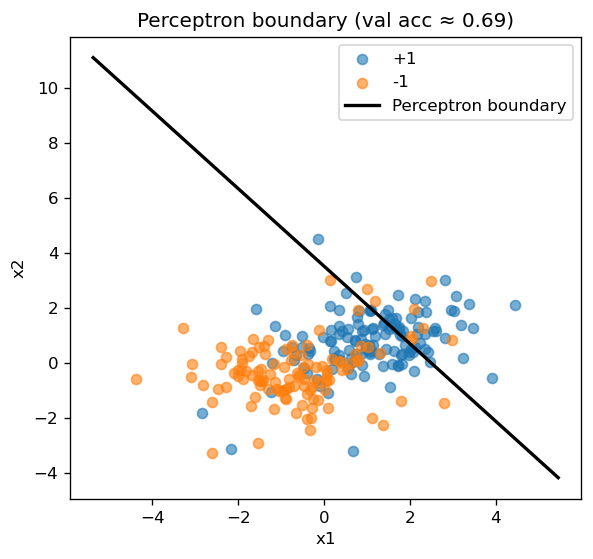

In [12]:
def perceptron_train(X, y, epochs=20, shuffle=True, seed=0):
    rng_local = np.random.default_rng(seed)
    w = np.zeros(X.shape[1], dtype=float)
    b = 0.0
    hist = []
    for ep in range(epochs):
        idx = np.arange(len(X))
        if shuffle:
            rng_local.shuffle(idx)
        mistakes = 0
        for i in idx:
            xi, yi = X[i], y[i]
            if yi * (w @ xi - b) <= 0:
                w += yi * xi
                b += yi
                mistakes += 1
        # track accuracy on training set
        acc_tr = (np.sign(X @ w - b) == y).mean()
        hist.append((acc_tr, mistakes))
        print(f"Epoch {ep+1:2d}: train_acc={acc_tr:.3f}, mistakes={mistakes}")
    return w, b, hist

def perceptron_accuracy(X, y, w, b):
    return (np.sign(X @ w - b) == y).mean()

# Train
w_p, b_p, hist_p = perceptron_train(Xc_tr, yc_tr, epochs=25, shuffle=True, seed=1)

# Evaluate
acc_tr = perceptron_accuracy(Xc_tr, yc_tr, w_p, b_p)
acc_va = perceptron_accuracy(Xc_va, yc_va, w_p, b_p)
print(f"\nPerceptron accuracy: train={acc_tr:.3f}, val={acc_va:.3f}")

# Plot boundary (on all points)
xx = np.linspace(X_cls[:,0].min()-1, X_cls[:,0].max()+1, 300)
plt.figure(figsize=(5.5,5))
plt.scatter(X_cls[y_cls==1,0],  X_cls[y_cls==1,1],  alpha=0.6, label="+1")
plt.scatter(X_cls[y_cls==-1,0], X_cls[y_cls==-1,1], alpha=0.6, label="-1")
if abs(w_p[1]) > 1e-10:
    yy = (b_p - w_p[0]*xx) / w_p[1]
    plt.plot(xx, yy, color="k", linewidth=2, label="Perceptron boundary")
else:
    # vertical boundary x1 = b / w1 (if w2 ~ 0)
    x_vert = b_p / (w_p[0] + 1e-12)
    plt.axvline(x_vert, color="k", linewidth=2, label="Perceptron boundary")
plt.title(f"Perceptron boundary (val acc ≈ {acc_va:.2f})")
plt.xlabel("x1"); plt.ylabel("x2"); plt.legend(); plt.show()
